# Bayesian Network with NumPy Arrays: Houseplant Care 🪴

A **Bayesian Network (BN)** has two parts:
1. A **DAG**: nodes are random variables, and arrows show direct influence.
2. A **CPT** for every node: `P(node | parents)`.

The chain rule turns them into one joint distribution:

$$P(X_1, \dots, X_n) = \prod_i P(X_i \mid \text{Parents}(X_i))$$

### The story (synthetic dataset)
A plant shop tracks the houseplants (pothos, monstera, snake plants) it sells, and follows up with each buyer a month later:

| Variable | Values | Meaning |
|---|---|---|
| `Window` | North / East / South | Which direction the plant's window faces |
| `Watering` | Rare / Weekly / Daily | How often the owner waters it |
| `Drainage` | Poor / Good | Does the pot have drainage holes? |
| `Light` | Low / Bright | How much light the plant gets |
| `Soil_Moisture` | Dry / Moist / Soggy | State of the soil |
| `Root_Rot` | No / Yes | Rotting roots from too much water |
| `Fungus_Gnats` | No / Yes | Small flies that breed in wet soil |
| `Leaf_Color` | Green / Yellow / Brown | What the leaves look like after a month |

**How this notebook's code differs:** everything is a **NumPy array**. States are stored as integers, and each CPT is an array with shape `(parent sizes..., node size)`. Sampling is vectorized. Learning uses `np.add.at`. The **whole joint distribution is a single 8-dimensional array** built with one `np.einsum` call, and inference is just slicing and summing that array.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

rng = np.random.default_rng(11)

## 1. Network structure

In [2]:
NODES = ["Window", "Watering", "Drainage", "Light",
         "Soil_Moisture", "Root_Rot", "Fungus_Gnats", "Leaf_Color"]

STATES = {
    "Window":        ["North", "East", "South"],
    "Watering":      ["Rare", "Weekly", "Daily"],
    "Drainage":      ["Poor", "Good"],
    "Light":         ["Low", "Bright"],
    "Soil_Moisture": ["Dry", "Moist", "Soggy"],
    "Root_Rot":      ["No", "Yes"],
    "Fungus_Gnats":  ["No", "Yes"],
    "Leaf_Color":    ["Green", "Yellow", "Brown"],
}

PARENTS = {
    "Window": [], "Watering": [], "Drainage": [],
    "Light":         ["Window"],
    "Soil_Moisture": ["Watering", "Drainage"],
    "Root_Rot":      ["Soil_Moisture"],
    "Fungus_Gnats":  ["Soil_Moisture"],
    "Leaf_Color":    ["Light", "Root_Rot"],
}

IDX  = {n: i for i, n in enumerate(NODES)}      # node name -> column / axis number
CARD = [len(STATES[n]) for n in NODES]          # number of states per node

for n in NODES:
    shape = tuple(CARD[IDX[p]] for p in PARENTS[n]) + (CARD[IDX[n]],)
    print(f"{n:14s} parents={PARENTS[n]!s:28s} CPT shape={shape}")

Window         parents=[]                           CPT shape=(3,)
Watering       parents=[]                           CPT shape=(3,)
Drainage       parents=[]                           CPT shape=(2,)
Light          parents=['Window']                   CPT shape=(3, 2)
Soil_Moisture  parents=['Watering', 'Drainage']     CPT shape=(3, 2, 3)
Root_Rot       parents=['Soil_Moisture']            CPT shape=(3, 2)
Fungus_Gnats   parents=['Soil_Moisture']            CPT shape=(3, 2)
Leaf_Color     parents=['Light', 'Root_Rot']        CPT shape=(2, 2, 3)


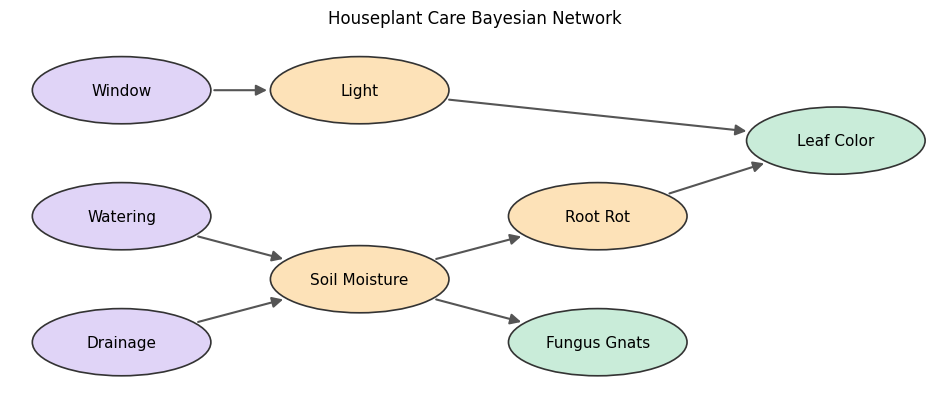

In [3]:
# Draw the DAG with ellipse patches; arrows are clipped to the ellipse edges
pos = {"Window": (0, 3), "Watering": (0, 1.5), "Drainage": (0, 0),
       "Light": (3.2, 3), "Soil_Moisture": (3.2, 0.75),
       "Root_Rot": (6.4, 1.5), "Fungus_Gnats": (6.4, 0),
       "Leaf_Color": (9.6, 2.4)}
is_parent = {p for ps in PARENTS.values() for p in ps}

fig, ax = plt.subplots(figsize=(12, 4.8))
shapes = {}
for n, (x, y) in pos.items():
    color = "#e0d4f7" if not PARENTS[n] else ("#fde2b8" if n in is_parent else "#c9ecd9")
    shapes[n] = Ellipse((x, y), 2.4, 0.8, fc=color, ec="#333", lw=1.2)
    ax.add_patch(shapes[n])
    ax.text(x, y, n.replace("_", " "), ha="center", va="center", fontsize=11)
for child in NODES:
    for p in PARENTS[child]:
        ax.annotate("", xy=pos[child], xytext=pos[p],
                    arrowprops=dict(arrowstyle="-|>", color="#555", lw=1.5, mutation_scale=16,
                                    patchA=shapes[p], patchB=shapes[child]))
ax.set_xlim(-1.5, 11); ax.set_ylim(-0.7, 3.7); ax.axis("off")
ax.set_title("Houseplant Care Bayesian Network")
plt.savefig("houseplant_dag.png", dpi=130, bbox_inches="tight")
plt.show()

## 2. Generate the dataset

Each true CPT is a NumPy array: the **last axis** is the node's own states, and the earlier axes are its parents (in the order listed in `PARENTS`).

In [4]:
TRUE = {
    "Window":   np.array([0.40, 0.35, 0.25]),            # North, East, South
    "Watering": np.array([0.25, 0.50, 0.25]),            # Rare, Weekly, Daily
    "Drainage": np.array([0.35, 0.65]),                  # Poor, Good
    "Light": np.array([[0.80, 0.20],                     # North -> Low, Bright
                       [0.45, 0.55],                     # East
                       [0.15, 0.85]]),                   # South
    "Soil_Moisture": np.array([                          # [Watering][Drainage] -> Dry, Moist, Soggy
        [[0.70, 0.28, 0.02], [0.85, 0.14, 0.01]],        # Rare:   Poor / Good drainage
        [[0.10, 0.60, 0.30], [0.20, 0.70, 0.10]],        # Weekly
        [[0.02, 0.28, 0.70], [0.05, 0.55, 0.40]],        # Daily
    ]),
    "Root_Rot":     np.array([[0.97, 0.03], [0.90, 0.10], [0.40, 0.60]]),   # Dry/Moist/Soggy -> No, Yes
    "Fungus_Gnats": np.array([[0.95, 0.05], [0.75, 0.25], [0.30, 0.70]]),
    "Leaf_Color": np.array([                             # [Light][Root_Rot] -> Green, Yellow, Brown
        [[0.55, 0.35, 0.10], [0.15, 0.45, 0.40]],        # Low light:    no rot / rot
        [[0.85, 0.12, 0.03], [0.25, 0.40, 0.35]],        # Bright light
    ]),
}

assert all(np.allclose(t.sum(axis=-1), 1) for t in TRUE.values())

In [5]:
def sample(cpts, n):
    """Sample n plants at once. X[i, j] = state number of node j for plant i."""
    X = np.zeros((n, len(NODES)), dtype=int)
    for node in NODES:
        parent_vals = tuple(X[:, IDX[p]] for p in PARENTS[node])
        probs = np.broadcast_to(cpts[node][parent_vals], (n, CARD[IDX[node]]))  # one row per plant
        u = rng.random((n, 1))
        X[:, IDX[node]] = (u > probs.cumsum(axis=1)).sum(axis=1)   # inverse-CDF sampling
    return X

X = sample(TRUE, 3000)
plants = pd.DataFrame({n: np.array(STATES[n])[X[:, IDX[n]]] for n in NODES})
plants.to_csv("houseplant_care.csv", index=False)
plants.head(10)

,Window,Watering,Drainage,Light,Soil_Moisture,Root_Rot,Fungus_Gnats,Leaf_Color
0,North,Daily,Good,Low,Soggy,Yes,Yes,Yellow
1,East,Rare,Good,Low,Dry,No,No,Yellow
2,East,Daily,Poor,Bright,Soggy,No,Yes,Green
3,North,Weekly,Good,Low,Moist,Yes,Yes,Green
4,North,Weekly,Good,Low,Dry,No,No,Yellow
5,South,Weekly,Good,Bright,Moist,No,No,Green
6,North,Rare,Good,Low,Dry,No,No,Yellow
7,North,Weekly,Good,Low,Dry,No,No,Green
8,South,Daily,Good,Bright,Moist,No,No,Green
9,East,Rare,Good,Bright,Moist,Yes,Yes,Green


In [6]:
# Quick look at the raw data: root rot rate for each watering habit
pd.crosstab(plants.Watering, plants.Root_Rot, normalize="index").round(2)

Root_Rot,No,Yes
Watering,,
Daily,0.63,0.37
Rare,0.95,0.05
Weekly,0.84,0.16


## 3. Learn the CPTs from the data

1. Read the CSV back and **encode** each label as its state number.
2. For each node, create a count array with the same shape as its CPT, filled with `alpha = 1` (Laplace smoothing).
3. `np.add.at` adds 1 at the position `(parent values..., node value)` for every row.
4. Normalize along the last axis.

In [7]:
df = pd.read_csv("houseplant_care.csv")
X_data = np.column_stack([df[n].map({s: i for i, s in enumerate(STATES[n])}) for n in NODES])

def learn_cpt(X, node, alpha=1):
    """Count into an array shaped like the CPT, then normalise over the last axis."""
    cols = [IDX[p] for p in PARENTS[node]] + [IDX[node]]
    counts = np.full([CARD[c] for c in cols], alpha, dtype=float)
    np.add.at(counts, tuple(X[:, c] for c in cols), 1)
    return counts / counts.sum(axis=-1, keepdims=True)

cpts = {n: learn_cpt(X_data, n) for n in NODES}
cpts["Soil_Moisture"].round(3)

array([[[0.688, 0.281, 0.031],
        [0.875, 0.112, 0.012]],

       [[0.097, 0.627, 0.276],
        [0.2  , 0.697, 0.103]],

       [[0.024, 0.264, 0.712],
        [0.052, 0.529, 0.419]]])

In [8]:
def cpt_frame(node, cpt):
    """Flatten a CPT array into a DataFrame (rows = parent combos)."""
    pa = PARENTS[node]
    index = pd.MultiIndex.from_product([STATES[p] for p in pa], names=pa) if pa else ["P"]
    return pd.DataFrame(cpt.reshape(-1, cpt.shape[-1]), index=index, columns=STATES[node]).round(3)

for n in NODES:
    print(f"P({n} | {', '.join(PARENTS[n]) or '-'})")
    display(cpt_frame(n, cpts[n]))

P(Window | -)


,North,East,South
P,0.41,0.35,0.239


P(Watering | -)


,Rare,Weekly,Daily
P,0.243,0.515,0.241


P(Drainage | -)


...

,No,Yes
Soil_Moisture,,
Dry,0.962,0.038
Moist,0.913,0.087
Soggy,0.403,0.597


P(Fungus_Gnats | Soil_Moisture)


,No,Yes
Soil_Moisture,,
Dry,0.944,0.056
Moist,0.769,0.231
Soggy,0.286,0.714


P(Leaf_Color | Light, Root_Rot)


Green  Yellow  Brown
Light  Root_Rot                      
Low    No        0.574   0.327  0.099
       Yes       0.144   0.435  0.421
Bright No        0.847   0.121  0.031
       Yes       0.265   0.422  0.313

## 4. The full joint distribution in one `einsum`

Give every node a letter (Window = `a`, Watering = `b`, …). Each CPT then becomes an einsum input such as `bce` (Watering, Drainage → Soil_Moisture). Writing all the inputs and asking for the output `abcdefgh` multiplies every CPT together **for every assignment at once**. That is the chain rule, and the result is an 8-dimensional array with 3·3·2·2·3·2·2·3 = 1296 cells.

In [9]:
LETTERS = {n: "abcdefgh"[i] for i, n in enumerate(NODES)}

def joint_tensor(cpts):
    """Chain rule for every assignment at once: one einsum multiplies all CPTs together."""
    inputs = ",".join("".join(LETTERS[p] for p in PARENTS[n] + [n]) for n in NODES)
    output = "".join(LETTERS[n] for n in NODES)
    return np.einsum(f"{inputs}->{output}", *(cpts[n] for n in NODES))

J = joint_tensor(cpts)
print("einsum:", ",".join("".join(LETTERS[p] for p in PARENTS[n] + [n]) for n in NODES), "-> abcdefgh")
print("shape:", J.shape, " total probability:", round(J.sum(), 6))

einsum: a,b,c,ad,bce,ef,eg,dfh -> abcdefgh
shape: (3, 3, 2, 2, 3, 2, 2, 3)  total probability: 1.0


In [10]:
def prob(assignment):
    """P(full assignment) is just one cell of the joint array."""
    return J[tuple(STATES[n].index(assignment[n]) for n in NODES)]

happy_plant = {"Window": "South", "Watering": "Weekly", "Drainage": "Good", "Light": "Bright",
               "Soil_Moisture": "Moist", "Root_Rot": "No", "Fungus_Gnats": "No",
               "Leaf_Color": "Green"}
print("P(perfectly happy plant) =", round(prob(happy_plant), 4))

P(perfectly happy plant) = 0.028


## 5. Inference = slice + sum

`P(target | evidence)`:
1. **Slice** the joint array at the evidence values. We use `i:i+1` so the axis is kept.
2. **Sum** over every axis except the target's.
3. **Normalize**.

In [11]:
def query(target, evidence={}, joint=None):
    """Exact P(target | evidence) by slicing and summing the joint array."""
    T = J if joint is None else joint
    index = [slice(None)] * len(NODES)
    for name, value in evidence.items():
        i = STATES[name].index(value)
        index[IDX[name]] = slice(i, i + 1)
    other_axes = tuple(a for a in range(len(NODES)) if a != IDX[target])
    p = T[tuple(index)].sum(axis=other_axes)
    return pd.Series(p / p.sum(), index=STATES[target]).round(3)

## 6. Asking the network questions

**Q1. What do customers' plants look like after a month?**

In [12]:
query("Leaf_Color")

Green     0.613
Yellow    0.265
Brown     0.122
dtype: float64

**Q2. Daily watering: how much does a pot with drainage holes help against root rot?**

In [13]:
pd.DataFrame({
    "Daily + poor drainage": query("Root_Rot", {"Watering": "Daily", "Drainage": "Poor"}),
    "Daily + good drainage": query("Root_Rot", {"Watering": "Daily", "Drainage": "Good"}),
})

,Daily + poor drainage,Daily + good drainage
No,0.551,0.702
Yes,0.449,0.298


**Q3. A customer says the leaves are Brown. How often were they watering?** (Diagnosis: reasoning from the symptom back to the habit.)

In [14]:
pd.DataFrame({
    "Prior":            query("Watering"),
    "Leaf_Color=Brown": query("Watering", {"Leaf_Color": "Brown"}),
})

,Prior,Leaf_Color=Brown
Rare,0.243,0.167
Weekly,0.515,0.490
Daily,0.241,0.343


**Q4. Explaining away.** The leaves are Yellow. Is it root rot?

- Yellow leaves make root rot more likely.
- If we also learn the plant sits by a **north window with Low light**, low light already explains the yellowing, so root rot becomes less likely.

In [15]:
pd.DataFrame({
    "Prior":                     query("Root_Rot"),
    "Yellow leaves":             query("Root_Rot", {"Leaf_Color": "Yellow"}),
    "Yellow leaves + Low light": query("Root_Rot", {"Leaf_Color": "Yellow", "Light": "Low"}),
})

,Prior,Yellow leaves,Yellow leaves + Low light
No,0.817,0.704,0.77
Yes,0.183,0.296,0.23


**Q5. Fungus gnats as a warning sign.** Gnats and root rot share a common cause (soggy soil), so spotting gnats should raise the chance of root rot, even though gnats do not cause rot.

In [16]:
pd.DataFrame({
    "No gnats seen": query("Root_Rot", {"Fungus_Gnats": "No"}),
    "Gnats seen":    query("Root_Rot", {"Fungus_Gnats": "Yes"}),
})

,No gnats seen,Gnats seen
No,0.888,0.639
Yes,0.112,0.361


## 7. Sanity checks

In [17]:
# 1. BN answer (learned and true CPTs) vs. raw frequency in the data
J_true = joint_tensor(TRUE)
freq = plants[plants.Watering == "Daily"].Leaf_Color.value_counts(normalize=True)
pd.DataFrame({
    "BN (learned)":   query("Leaf_Color", {"Watering": "Daily"}),
    "BN (true CPTs)": query("Leaf_Color", {"Watering": "Daily"}, joint=J_true),
    "Data frequency": freq.reindex(STATES["Leaf_Color"]).round(3),
})

,BN (learned),BN (true CPTs),Data frequency
Green,0.528,0.522,0.540
Yellow,0.299,0.304,0.273
Brown,0.173,0.174,0.186


In [18]:
# 2. Learned vs true CPTs: the arrays have the same shape, so we can subtract them directly
max_gap = max(np.abs(cpts[n] - TRUE[n]).max() for n in NODES)
print(f"Largest |learned - true| over all CPT entries: {max_gap:.3f}")

Largest |learned - true| over all CPT entries: 0.037


## Summary

- An 8-node Bayesian Network for houseplant care, built with **only NumPy arrays**.
- **Data:** vectorized inverse-CDF sampling of 3000 plants in a few lines.
- **Learning:** `np.add.at` counting into CPT-shaped arrays, with Laplace smoothing.
- **Joint distribution:** one `np.einsum` call (the chain rule for all 1296 assignments).
- **Inference:** slice at the evidence, sum out the other axes, normalize.
- The network covers predictive (Watering → Root rot), diagnostic (Brown → Watering), **explaining-away** (Low light vs Root rot) and **common-cause** (Gnats ↔ Root rot) reasoning.